# Persistent homology and attention: visual results

**Research question:** does a topological representation make it easier to identify the three people with a simple model? Does an attention model provide an additional improvement?

This notebook reads saved results without retraining any models. Figures are displayed below and exported to `results/presentation/`.

**Overview:** shared protocol → performance → errors → attention learning curves → complexity → conclusions.

Open with the `.venv` kernel and run from the project root.

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
from IPython.display import Markdown, display

%matplotlib inline

ROOT = Path.cwd()
BASELINE_PATH = ROOT / "results/baseline/metrics.json"
ATTENTION_PATH = ROOT / "results/attention/metrics.json"
if not BASELINE_PATH.exists() or not ATTENTION_PATH.exists():
    raise FileNotFoundError("Run this notebook from the project root after baseline.py and train_attention.py.")
baseline = json.loads(BASELINE_PATH.read_text())
attention = json.loads(ATTENTION_PATH.read_text())

# Reject comparisons involving different data, partitions, or sample order.
assert baseline["data_sha256"] == attention["data_sha256"], "Different datasets"
assert baseline["split_indices"] == attention["split_indices"], "Different partitions"
assert baseline["test_labels"] == attention["test_labels"], "Different test label order"
assert baseline["classes"] == attention["classes"], "Different class encoding"

models = [
    {"name": "Logistic regression · raw", "short": "Raw data", "scores": baseline["models"]["raw"],
     "parameters": baseline["models"]["raw"]["n_parameters"], "color": "#2563EB"},
    {"name": "Logistic regression · TDA + ATOL", "short": "TDA + ATOL", "scores": baseline["models"]["tda_atol"],
     "parameters": baseline["models"]["tda_atol"]["n_parameters"], "color": "#008C80"},
    {"name": "Attention · TDA", "short": "Attention TDA", "scores": attention["scores"],
     "parameters": attention["n_parameters"], "color": "#7C3AED"},
]
classes = baseline["classes"]
y_test = np.array(baseline["test_labels"])
n_test = len(y_test)
for model in models:
    predictions = np.array(model["scores"]["test"]["predictions"])
    assert predictions.shape == y_test.shape
    assert np.isclose(np.mean(predictions == y_test), model["scores"]["test"]["accuracy"])
    expected_matrix = np.array([
        [np.sum((y_test == i) & (predictions == j)) for j in range(3)] for i in range(3)
    ])
    np.testing.assert_array_equal(expected_matrix, model["scores"]["test"]["confusion_matrix"])

OUTPUT = ROOT / "results/presentation"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 170, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.labelcolor": "#334155",
    "text.color": "#0F172A", "axes.edgecolor": "#CBD5E1",
    "figure.facecolor": "white", "axes.facecolor": "white",
})


def show_and_save(figure, name):
    # Export the exact figure displayed in the notebook.
    figure.savefig(OUTPUT / f"{name}.png", bbox_inches="tight", facecolor="white")
    plt.show()


## 1. A shared protocol for comparing models

All three models use **the same samples**: 180 for training, 60 for validation, and 60 for testing. Each split contains equal numbers of samples from A, B, and C.

- **Raw data:** 200 measurements × 3 coordinates, flattened into 600 features and standardized.
- **TDA + ATOL:** finite H0/H1 intervals, vectorized into 40 features and standardized; logistic regression.
- **TDA attention:** standardized birth/death points fed directly into two attention blocks, with an explicit padding mask and a learned CLS token; no ATOL.

Scaling statistics and ATOL centers are fitted on training data only. Validation selects `C` for logistic regression and the checkpoint epoch for attention. The test split is used for final evaluation. Validation scores are therefore not an independent performance estimate.

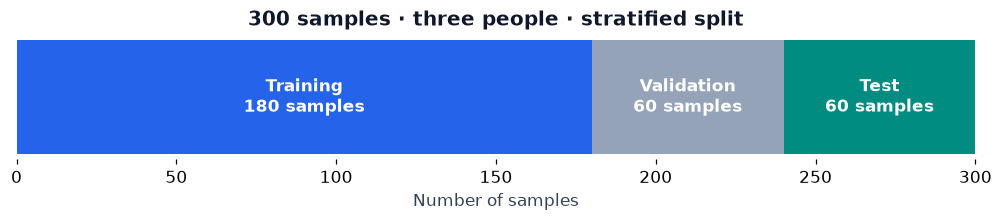

In [2]:
sizes = {name: len(indices) for name, indices in baseline["split_indices"].items()}
fig, ax = plt.subplots(figsize=(9, 1.9), layout="constrained")
left = 0
for (name, size), color, label in zip(sizes.items(), ["#2563EB", "#94A3B8", "#008C80"],
                                     ["Training", "Validation", "Test"]):
    ax.barh(0, size, left=left, color=color, height=0.5)
    ax.text(left + size / 2, 0, f"{label}\n{size} samples", ha="center", va="center", color="white", weight="bold")
    left += size
ax.set(xlim=(0, left), yticks=[], xlabel="Number of samples", title="300 samples · three people · stratified split")
ax.spines[["left", "bottom"]].set_visible(False)
show_and_save(fig, "01_partitions")


## 2. Performance: accuracy and error counts

Accuracy is the fraction of correctly classified samples. **Macro F1** gives equal weight to each of the three people.

The training scores below are evaluated after fitting. For attention, all these scores use the selected checkpoint with dropout disabled.

| Model | Train | Validation | Test | Test macro F1 | Test errors |
|---|---:|---:|---:|---:|---:|
| Logistic regression · raw | 100.0% | 88.3% | 91.7% | 0.915 | 5/60 |
| Logistic regression · TDA + ATOL | 100.0% | 100.0% | 100.0% | 1.000 | 0/60 |
| Attention · TDA | 99.4% | 96.7% | 96.7% | 0.967 | 2/60 |

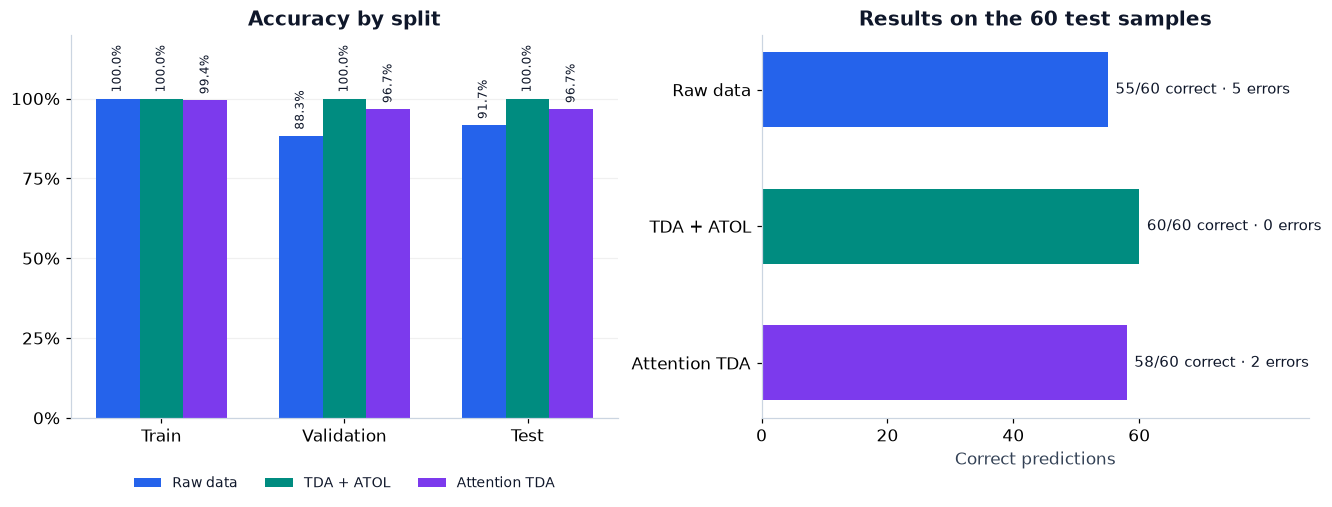

In [3]:
rows = ["| Model | Train | Validation | Test | Test macro F1 | Test errors |",
        "|---|---:|---:|---:|---:|---:|"]
for model in models:
    scores = model["scores"]
    errors = int(np.sum(np.array(scores["test"]["predictions"]) != y_test))
    accuracies = " | ".join(f"{scores[split]['accuracy']:.1%}" for split in ["train", "validation", "test"])
    rows.append(f"| {model['name']} | {accuracies} | {scores['test']['macro_f1']:.3f} | {errors}/{n_test} |")
display(Markdown("\n".join(rows)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
x = np.arange(3)
width = 0.24
for offset, model in enumerate(models):
    scores = [model["scores"][split]["accuracy"] for split in ["train", "validation", "test"]]
    bars = axes[0].bar(x + (offset - 1) * width, scores, width, color=model["color"], label=model["short"])
    axes[0].bar_label(bars, labels=[f"{v:.1%}" for v in scores], fontsize=8, padding=4, rotation=90)
axes[0].set(xticks=x, xticklabels=["Train", "Validation", "Test"], ylim=(0, 1.2), title="Accuracy by split")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_yticks([0, .25, .5, .75, 1])
axes[0].grid(axis="y", alpha=0.18)
axes[0].set_axisbelow(True)
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=9)

correct = [int(np.sum(np.array(m["scores"]["test"]["predictions"]) == y_test)) for m in models]
bars = axes[1].barh([m["short"] for m in models], correct, color=[m["color"] for m in models], height=0.55)
axes[1].bar_label(bars, labels=[f"{n}/{n_test} correct · {n_test-n} errors" for n in correct], padding=5, fontsize=10)
axes[1].set(xlim=(0, n_test * 1.45), xlabel="Correct predictions", title=f"Results on the {n_test} test samples")
axes[1].set_xticks([0, 20, 40, 60])
axes[1].invert_yaxis()
show_and_save(fig, "02_performances")


## 3. Where do the errors occur?

Confusion matrices show the true person in each row and the predicted person in each column. Diagonal entries are correct classifications. All three plots use the same color scale.

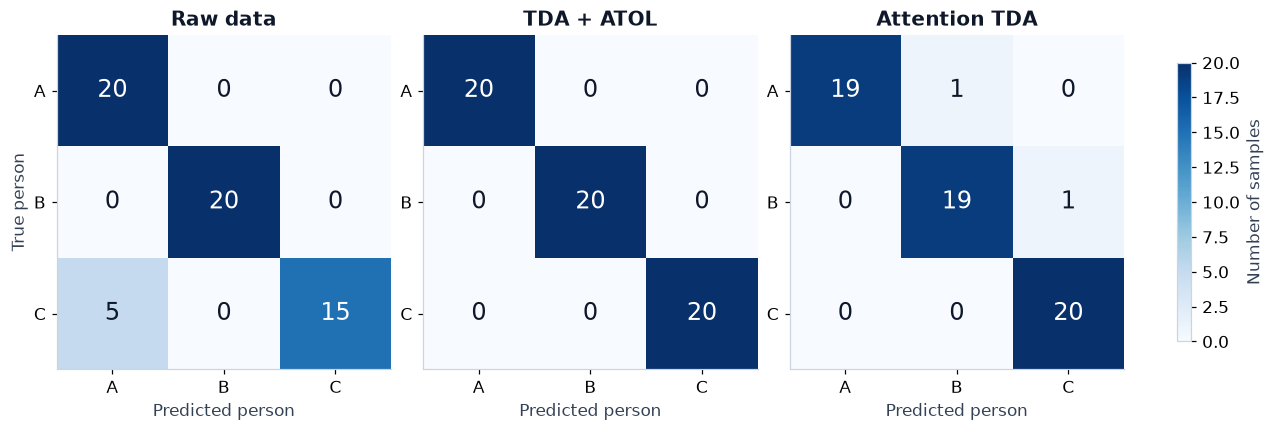

In [4]:
matrices = [np.array(m["scores"]["test"]["confusion_matrix"]) for m in models]
vmax = max(matrix.max() for matrix in matrices)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), layout="constrained")
for ax, model, matrix in zip(axes, models, matrices):
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)
    ax.set(xticks=range(3), yticks=range(3), xticklabels=classes, yticklabels=classes,
           xlabel="Predicted person", title=model["short"])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=16,
                    color="white" if matrix[i, j] > vmax / 2 else "#0F172A")
axes[0].set_ylabel("True person")
fig.colorbar(image, ax=axes, shrink=0.78, label="Number of samples")
show_and_save(fig, "03_confusion")


### Sample-by-sample comparison

Each column below represents **the same test sample** for all three models. Columns are grouped by the true person. Green indicates a correct prediction; red indicates an error.

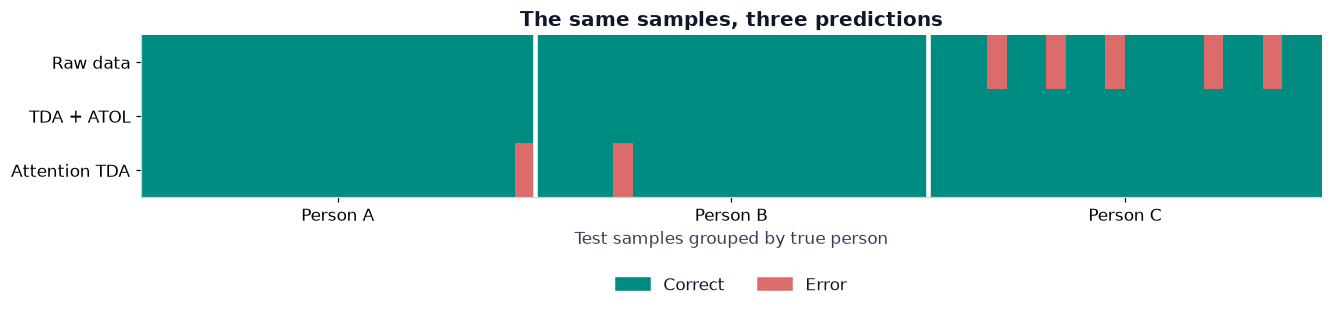

In [5]:
order = np.argsort(y_test, kind="stable")
correctness = np.array([
    (np.array(m["scores"]["test"]["predictions"]) == y_test)[order] for m in models
])
fig, ax = plt.subplots(figsize=(12, 2.7), layout="constrained")
ax.imshow(correctness, cmap=ListedColormap(["#DC6B6B", "#008C80"]), vmin=0, vmax=1, aspect="auto", interpolation="nearest")
ax.set(yticks=range(3), yticklabels=[m["short"] for m in models], xlabel="Test samples grouped by true person",
       title="The same samples, three predictions")
centers = []
left = 0
for person in range(3):
    count = int(np.sum(y_test == person))
    centers.append(left + (count - 1) / 2)
    if left:
        ax.axvline(left - .5, color="white", linewidth=3)
    left += count
ax.set_xticks(centers, [f"Person {label}" for label in classes])
ax.legend(handles=[Patch(color="#008C80", label="Correct"), Patch(color="#DC6B6B", label="Error")],
          loc="upper center", bbox_to_anchor=(0.5, -0.4), ncol=2, frameon=False)
show_and_save(fig, "04_predictions_appariees")


## 4. How does the attention model learn?

Early stopping monitors **validation loss**, rather than test accuracy. The vertical line marks the epoch whose weights are restored.

These curves show metrics recorded during training: dropout is active for training and disabled for validation. They may therefore differ from the scores recomputed after restoring the selected checkpoint.

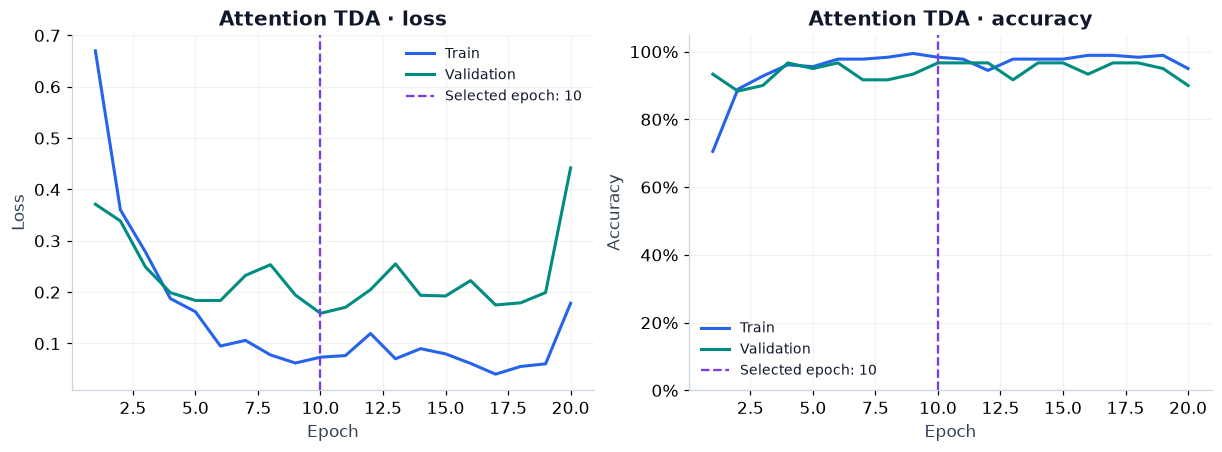

**Stopped after 20 epochs; weights from epoch 10 restored.**

In [6]:
history = attention["history"]
epochs = np.arange(1, attention["epochs_run"] + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metric, label in zip(axes, ["loss", "accuracy"], ["Loss", "Accuracy"]):
    ax.plot(epochs, history[metric], color="#2563EB", label="Train", linewidth=2)
    ax.plot(epochs, history["val_" + metric], color="#008C80", label="Validation", linewidth=2)
    ax.axvline(attention["best_epoch"], color="#7C3AED", linestyle="--", label=f"Selected epoch: {attention['best_epoch']}")
    ax.set(xlabel="Epoch", ylabel=label, title=f"Attention TDA · {label.lower()}")
    ax.grid(alpha=.15)
    ax.legend(frameon=False, fontsize=9)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_ylim(0, 1.05)
show_and_save(fig, "05_apprentissage_attention")
display(Markdown(f"**Stopped after {attention['epochs_run']} epochs; weights from epoch {attention['best_epoch']} restored.**"))


## 5. Classifier performance and complexity

The parameter count includes the weights and biases of the **classifier**. It excludes the centers learned by ATOL and the cost of computing persistence diagrams. Both logistic regressions belong to the same model family, but use different numbers of input features.

This plot compares classifier sizes; it does not measure execution time or the total preprocessing cost.

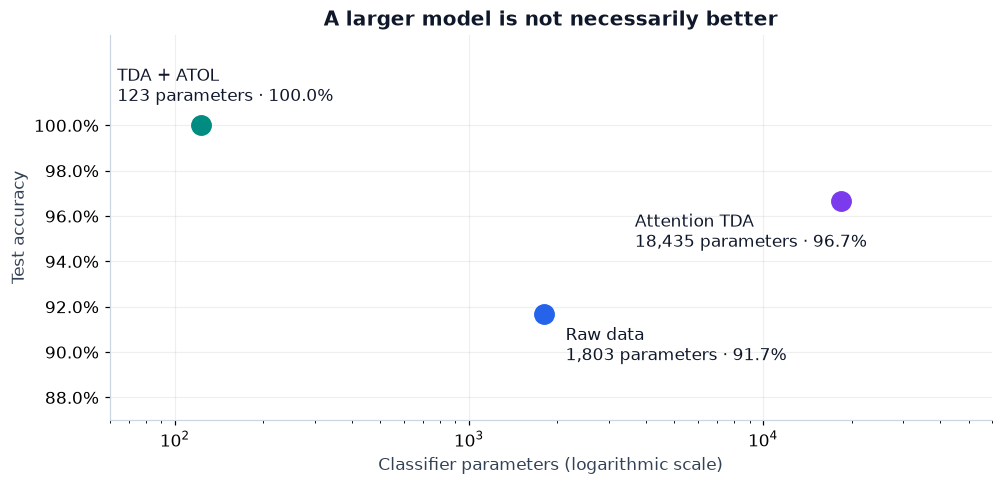

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.3), layout="constrained")
for model, offset in zip(models, [(14, -30), (-55, 16), (-135, -30)]):
    score = model["scores"]["test"]["accuracy"]
    ax.scatter(model["parameters"], score, s=160, color=model["color"], zorder=3)
    ax.annotate(f"{model['short']}\n{model['parameters']:,} parameters · {score:.1%}",
                (model["parameters"], score), xytext=offset, textcoords="offset points", fontsize=11)
ax.set(xscale="log", xlim=(60, 60000), ylim=(0.87, 1.04),
       xlabel="Classifier parameters (logarithmic scale)",
       ylabel="Test accuracy", title="A larger model is not necessarily better")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_yticks(np.arange(.88, 1.001, .02))
ax.grid(alpha=.2, which="major")
show_and_save(fig, "06_complexite")


## 6. What can we conclude from this experiment?

The **raw data versus TDA + ATOL** comparison examines the effect of changing the representation while using logistic regression. The **TDA + ATOL versus TDA attention** comparison changes both the representation supplied to the classifier and the model family: it does not isolate the effect of attention alone.

Results apply to one split and to identifying these three known people. Acquisition sessions are not identified in the data file, so independence between windows from the same recording cannot be guaranteed. Establishing general superiority would require additional evaluations defined before inspecting their test results.

In [8]:
raw, atol, attn = models
raw_accuracy = raw["scores"]["test"]["accuracy"]
atol_accuracy = atol["scores"]["test"]["accuracy"]
attn_accuracy = attn["scores"]["test"]["accuracy"]
gain = 100 * (atol_accuracy - raw_accuracy)
attention_relation = "does not outperform" if attn_accuracy <= atol_accuracy else "outperforms"
interpretation = ("TDA + ATOL preprocessing improves class separation by a linear model in this experiment."
                  if gain > 0 else "this test does not show an accuracy gain from TDA + ATOL preprocessing.")
display(Markdown(
    f"- **Topological representation + ATOL:** {atol_accuracy:.1%} on the test split, compared with {raw_accuracy:.1%} for raw data "
    f"(**{gain:+.1f} percentage points**), with 40 features instead of 600.\n"
    f"- **Attention on diagrams:** {attn_accuracy:.1%}; it {attention_relation} the TDA + ATOL logistic regression baseline on this split.\n"
    f"- **Interpretation:** {interpretation} "
    f"This result does not justify systematically favoring a more complex model."
))


- **Topological representation + ATOL:** 100.0% on the test split, compared with 91.7% for raw data (**+8.3 percentage points**), with 40 features instead of 600.
- **Attention on diagrams:** 96.7%; it does not outperform the TDA + ATOL logistic regression baseline on this split.
- **Interpretation:** TDA + ATOL preprocessing improves class separation by a linear model in this experiment. This result does not justify systematically favoring a more complex model.